# TASK 1

## 1.1 Load Data

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Region_summary_NSW.csv")
df.shape

(800, 15)

## 1.2 Clean Data

In [18]:
print(f'{df.info()}\n\n{df.isna().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        800 non-null    object 
 1   Parent Description  800 non-null    object 
 2   Description         800 non-null    object 
 3   2011                259 non-null    float64
 4   2015                20 non-null     float64
 5   2016                457 non-null    float64
 6   2017                48 non-null     float64
 7   2018                125 non-null    float64
 8   2019                270 non-null    float64
 9   2020                291 non-null    float64
 10  2021                692 non-null    float64
 11  2022                293 non-null    float64
 12  2023                207 non-null    float64
 13  2024                209 non-null    float64
 14  2025                3 non-null      float64
dtypes: float64(12), object(3)
memory usage: 93.9+ KB
None

Me

The non-null and null counts above reveal that several year columns are sparsely populated across the dataset. The table below summarises the null percentage for each year column. \
Columns with a high proportion (> 90%) of missing values will be dropped to ensure subsequent analysis remains meaningful.

In [22]:
year_cols = [c for c in df.columns if c.isdigit()]

# Determine null ratios for each year column
null_counts = df[year_cols].isnull().sum()
null_ratios = df[year_cols].isnull().mean()
null_percentage = null_ratios * 100

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_ratio': null_ratios.round(2),
    'null_percentage': null_percentage.round(2),
    'populated_count': df[year_cols].notna().sum(),
}).sort_values('null_ratio', ascending=False)

print(null_summary)

      null_count  null_ratio  null_percentage  populated_count
2025         797        1.00            99.62                3
2015         780        0.98            97.50               20
2017         752        0.94            94.00               48
2018         675        0.84            84.38              125
2023         593        0.74            74.12              207
2024         591        0.74            73.88              209
2011         541        0.68            67.62              259
2019         530        0.66            66.25              270
2020         509        0.64            63.62              291
2022         507        0.63            63.38              293
2016         343        0.43            42.88              457
2021         108        0.14            13.50              692


In [23]:
THRESHOLD = 0.90

drop_cols = null_ratios[null_ratios >= THRESHOLD].index.tolist()
keep_cols = null_ratios[null_ratios < THRESHOLD].index.tolist()

print('Drop: ', drop_cols)
print('Keep: ', keep_cols)

df = df.drop(columns = drop_cols)
df.shape

Drop:  ['2015', '2017', '2025']
Keep:  ['2011', '2016', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


(800, 12)

We noticed that all units of measure are located within the description columns, thus took steps to extract them.\
Utilising the `Measure Code`, we determined that a `Category` feature can be extracted to allow for easier querying logic in the future.  
Similarly the descriptions of each `Category` is extracted from the `Parent Description`.

In [26]:
df['Unit'] = np.where(
    df['Description'].str.strip().str.contains('number', na = False, case = False),
    'no.',
    df['Description'].str.strip().str.extract(r'\(([^)]+)\)$')[0]
)

df['Description_clean'] = (
    df['Description']
    .str.strip()
    .str.replace(r'\s*\([^)]+\)$', '',regex=True)
    .str.strip()
    )

df['Category'] = df['Measure Code'].str.extract(r'^([A-Z]+)')

df['Category_des'] = (
    df['Parent Description']
    .str.split(' - ')
    .str[0]
    .str.strip()
    )

df.head(5)

,Measure Code,Parent Description,Description,2011,2016,2018,2019,2020,2021,2022,2023,2024,Unit,Description_clean,Category,Category_des
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,no.,Estimated resident population,ERP,Estimated resident population
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,persons/km2,Population density,ERP,Estimated resident population
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,no.,Estimated resident population - males,ERP,Estimated resident population
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,no.,Estimated resident population - females,ERP,Estimated resident population
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,years,Median age - males,ERP,Estimated resident population


In [8]:
col_order = ['Category', 'Category_des', 'Description_clean', 'Unit', 
             '2011', '2016', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

# This would probs be the final dataset
df = df[col_order]
df.head(10)

,Category,Category_des,Description_clean,Unit,2011,2016,2018,2019,2020,2021,2022,2023,2024
0,ERP,Estimated resident population,Estimated resident population,no.,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0
1,ERP,Estimated resident population,Population density,persons/km2,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6
2,ERP,Estimated resident population,Estimated resident population - males,no.,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0
3,ERP,Estimated resident population,Estimated resident population - females,no.,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0
4,ERP,Estimated resident population,Median age - males,years,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5
5,ERP,Estimated resident population,Median age - females,years,NaN,NaN,NaN,38.6,39.0,39.5,39.6,39.4,39.4
6,ERP,Estimated resident population,Median age - persons,years,NaN,NaN,NaN,37.7,38.1,38.6,38.7,38.4,38.4
7,ERP,Estimated resident population,Working age population (aged 15-64 years),no.,NaN,NaN,NaN,5240576.0,5255515.0,5209700.0,5247219.0,5388091.0,5490199.0
8,ERP,Estimated resident population,Working age population (aged 15-64 years),%,NaN,NaN,NaN,65.1,64.8,64.3,64.3,64.6,64.7
9,ERP,Estimated resident population,Males - 0-4 years,no.,NaN,NaN,NaN,253365.0,250224.0,246488.0,247060.0,246330.0,243455.0


## 1.3 Derived Statistics

## Statistics:
- Old-Age Dependency Ratio
- Median Employee Wage Growth Rate (year-on-year %)
- Natural Population Growth Rate (per 1,000 people)
- Dwelling Density Rate
- Net Business Survival Score

Old-Age Dependency Ratio (persons 65+ per 100 working-age):
  2019: 25.08
  2020: 25.86
  2021: 26.75
  2022: 27.15
  2023: 27.09
  2024: 27.32
----------------------------------------
Shift 2019-2021: +1.67  →  Ageing pressure increasing
Shift 2021-2024: +0.57  →  Ageing pressure increasing
Total shift 2019-2024: +2.24


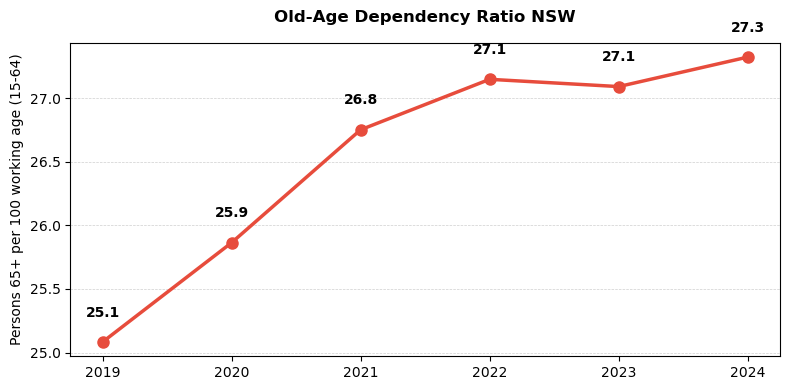

In [9]:
# Derived Statistic 1: Old-Age Dependency Ratio (oadr)
# Old-age dependency ratio = population 65+ / working-age population (15–64) × 100

erp=df[df['Category']=='ERP']
year_cols=['2019', '2020', '2021', '2022', '2023', '2024']

aged_65plus_labels = [
    'Males - 65-69 years', 'Males - 70-74 years', 'Males - 75-79 years', 'Males - 80-84 years', 'Males - 85 and over',
    'Females - 65-69 years', 'Females - 70-74 years', 'Females - 75-79 years', 'Females - 80-84 years', 'Females - 85 and over',
]

pop_65plus = erp[(erp['Description_clean'].isin(aged_65plus_labels)) & (erp['Unit']=='no.')][year_cols].sum(min_count=1)
working_age= erp[(erp['Description_clean']=='Working age population (aged 15-64 years)') & (erp['Unit']=='no.')][year_cols].squeeze()
oadr= pop_65plus/working_age *100

shift_19_21 = oadr['2021']- oadr['2019']
shift_21_24 = oadr['2024']-oadr['2021']
total_shift = oadr['2024']-oadr['2019']

print("Old-Age Dependency Ratio (persons 65+ per 100 working-age):")
for year in year_cols:
    print(f"  {year}: {oadr[year]:.2f}")
print("-" * 40)
print(f"Shift 2019-2021: {shift_19_21:+.2f}  →  {'Ageing pressure increasing' if shift_19_21 > 0 else 'Ageing pressure easing'}")
print(f"Shift 2021-2024: {shift_21_24:+.2f}  →  {'Ageing pressure increasing' if shift_21_24 > 0 else 'Ageing pressure easing'}")
print(f"Total shift 2019-2024: {total_shift:+.2f}")


#Visualisation
plt.figure(figsize=(8,4))
plt.plot(year_cols, oadr.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
plt.title('Old-Age Dependency Ratio NSW', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Persons 65+ per 100 working age (15-64)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i,v in enumerate(oadr.values):
  plt.text(i, v+0.2, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



Median Employee Wage Growth Rate:
  2018: $51,411
  2019: $53,104
  2020: $54,989
  2021: $57,891
  2022: $58,972
------------------------------
 Year-on-Year growth 2019: +3.29%
 Year-on-Year growth 2020: +3.55%
 Year-on-Year growth 2021: +5.28%
 Year-on-Year growth 2022: +1.87%
Total growth 2018-2022: +14.71%


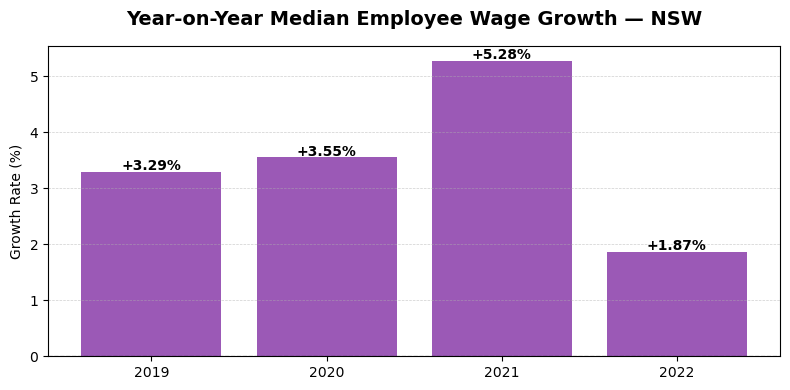

In [10]:
# Derived Statistic 2: Median Employee Wage Growth Rate (year-on-year %)
# Median Employee Wage Growth Rate= (median income this year − median income last year) / last year × 100

income = df[df['Category'] == 'INCOME']
year_cols_inc = ['2018', '2019', '2020', '2021', '2022']

median_income = income[income['Description_clean'] == 'Median employee income'][year_cols_inc].squeeze()
wage_growth = median_income.pct_change() * 100  # year-on-year % change
growth_years = year_cols_inc[1:]  # growth starts from 2nd year

total_growth = (median_income['2022'] - median_income['2018']) / median_income['2018'] * 100

print("\nMedian Employee Wage Growth Rate:")
for year in year_cols_inc:
    print(f"  {year}: ${median_income[year]:,.0f}")
print("-" * 30)
for year in growth_years:
    print(f" Year-on-Year growth {year}: {wage_growth[year]:+.2f}%")
print(f"Total growth 2018-2022: {total_growth:+.2f}%")

#visualisation
plt.figure(figsize=(8, 4))
plt.bar(growth_years, wage_growth[growth_years].values, color='#9b59b6')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Year-on-Year Median Employee Wage Growth — NSW', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Growth Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, (year, v) in enumerate(zip(growth_years, wage_growth[growth_years].values)):
    plt.text(i, v + 0.03, f"{v:+.2f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



Natural Population Growth Rate (per 1,000 people):
  2018: nan per 1,000  (births: 107,343, deaths: 53,633)
  2019: 5.32 per 1,000  (births: 98,906, deaths: 56,058)
  2020: 5.30 per 1,000  (births: 95,459, deaths: 52,485)
  2021: 5.53 per 1,000  (births: 101,332, deaths: 56,525)
  2022: 4.27 per 1,000  (births: 97,884, deaths: 62,980)
  2023: 3.90 per 1,000  (births: 91,947, deaths: 59,451)
----------------------------------------
Shift 2018-2021: +nan
Shift 2021-2023: -1.64
Total shift 2018-2023: +nan


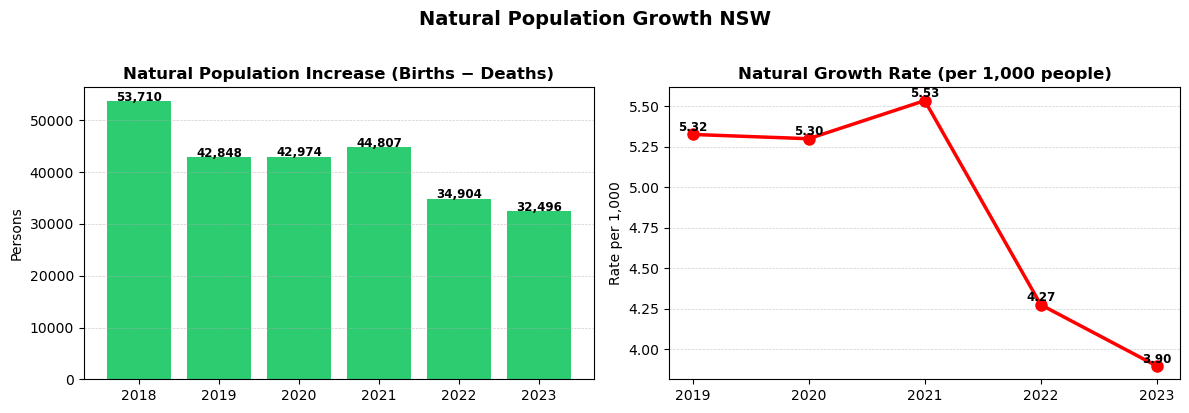

In [11]:
# Derived Statistic 3: Natural Population Growth Rate (per 1,000 people)
# Natural Population Growth Rate= (births − deaths) / total population × 1,000

bd = df[df['Category'] == 'BD']
year_cols_bd = ['2018', '2019', '2020', '2021', '2022', '2023']

births       = bd[bd['Description_clean'] == 'Births'][year_cols_bd].squeeze()
deaths       = bd[bd['Description_clean'] == 'Deaths'][year_cols_bd].squeeze()
total_pop_bd = erp[erp['Description_clean'] == 'Estimated resident population'][year_cols_bd].squeeze()

natural_increase = births - deaths
growth_rate      = natural_increase / total_pop_bd * 1000

first_shift  = growth_rate['2021'] - growth_rate['2018']
second_shift = growth_rate['2023'] - growth_rate['2021']
total_shift  = growth_rate['2023'] - growth_rate['2018']

print("\nNatural Population Growth Rate (per 1,000 people):")
for year in year_cols_bd:
    print(f"  {year}: {growth_rate[year]:.2f} per 1,000  (births: {int(births[year]):,}, deaths: {int(deaths[year]):,})")
print("-" * 40)
print(f"Shift 2018-2021: {first_shift:+.2f}")
print(f"Shift 2021-2023: {second_shift:+.2f}")
print(f"Total shift 2018-2023: {total_shift:+.2f}")

#visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(year_cols_bd, natural_increase.values, color='#2ecc71')
ax1.set_title('Natural Population Increase (Births − Deaths)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Persons')
ax1.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(natural_increase.values):
    ax1.text(i, v + 100, f"{int(v):,}", ha='center', fontsize=8.5, fontweight='bold')

ax2.plot(year_cols_bd, growth_rate.values, marker='o', color='red', linewidth=2.5, markersize=8)
ax2.set_title('Natural Growth Rate (per 1,000 people)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rate per 1,000')
ax2.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(growth_rate.values):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=8.5, fontweight='bold')

plt.suptitle('Natural Population Growth NSW', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Dwelling Density Rate (dwellings per 100 people):
  2019: 40.26  (dwellings: 3,239,814, population: 8,046,748)
  2020: 40.58  (dwellings: 3,291,260, population: 8,110,610)
  2021: 41.21  (dwellings: 3,336,762, population: 8,097,062)
  2022: 41.31  (dwellings: 3,373,885, population: 8,166,704)
----------------------------------------
Shift 2019-2021: +0.947
Shift 2021-2022: +0.103
Total shift 2019-2022: +1.050
Interpretation: An increasing rate indicates housing construction is keeping pace with population growth.


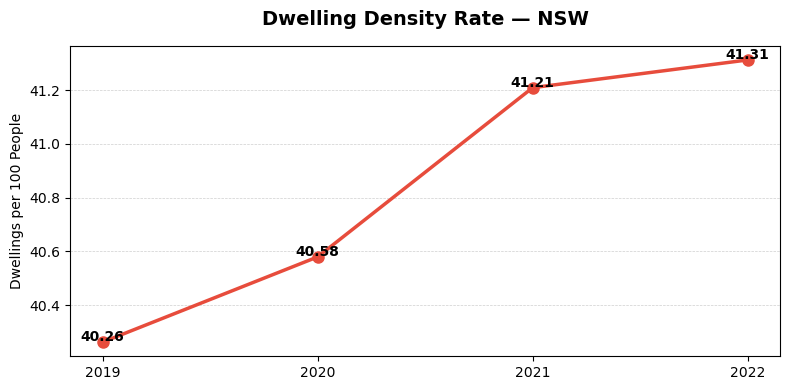

In [12]:
# Derived Statistic 4: Dwelling Density Rate
# Dwelling Density Rate= total dwellings / total population × 100

dwellstock = df[df['Category'] == 'DWELLSTOCK']
year_cols_d = ['2019', '2020', '2021', '2022']

total_dwellings = dwellstock[dwellstock['Description_clean'] == 'Total dwellings'][year_cols_d].squeeze()
total_pop_d     = erp[erp['Description_clean'] == 'Estimated resident population'][year_cols_d].squeeze()
density_rate    = total_dwellings / total_pop_d * 100

first_shift = density_rate['2021'] - density_rate['2019']
second_shift = density_rate['2022'] - density_rate['2021']
total_shift = density_rate['2022'] - density_rate['2019']

print("\nDwelling Density Rate (dwellings per 100 people):")
for year in year_cols_d:
    print(f"  {year}: {density_rate[year]:.2f}  (dwellings: {int(total_dwellings[year]):,}, population: {int(total_pop_d[year]):,})")
print("-" * 40)
print(f"Shift 2019-2021: {first_shift:+.3f}")
print(f"Shift 2021-2022: {second_shift:+.3f}")
print(f"Total shift 2019-2022: {total_shift:+.3f}")
print(f"Interpretation: {'A declining rate indicates population growth is outpacing housing construction, contributing to housing affordability pressure in NSW.' if total_shift < 0 else 'An increasing rate indicates housing construction is keeping pace with population growth.'}")

#visualisation
plt.figure(figsize=(8, 4))
plt.plot(year_cols_d, density_rate.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
plt.title('Dwelling Density Rate — NSW', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Dwellings per 100 People')
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(density_rate.values):
    plt.text(i, v + 0.003, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


Net Business Survival Score (%):
  2021: +3.89%  (entries: 128,251, exits: 96,444)
  2022: +4.43%  (entries: 143,465, exits: 105,636)
  2023: +1.07%  (entries: 138,094, exits: 128,785)
  2024: +2.95%  (entries: 149,226, exits: 122,778)
------------------------------
Shift 2021-2022: +0.54 pp
Shift 2022-2024: -1.48 pp
Total shift 2021-2024: -0.94 pp


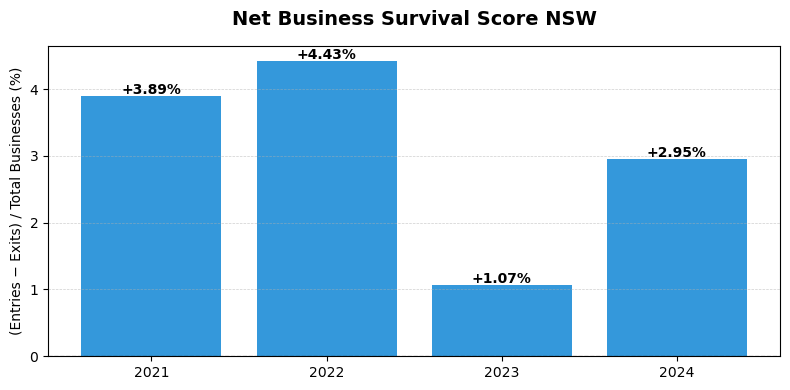

In [13]:
# Derived Statistic 5: Net Business Survival Score
# Net Business Survival Score: (entries − exits) / total businesses × 100

cabee = df[df['Category'] == 'CABEE']
year_cols_b = ['2021', '2022', '2023', '2024']

entries   = cabee[cabee['Description_clean'] == 'Total number of business entries'][year_cols_b].squeeze()
exits     = cabee[cabee['Description_clean'] == 'Total number of business exits'][year_cols_b].squeeze()
stock     = cabee[cabee['Description_clean'] == 'Total number of businesses'][year_cols_b].squeeze()
net_score = (entries - exits) / stock * 100

first_shift  = net_score['2022'] - net_score['2021']
second_shift = net_score['2024'] - net_score['2022']
total_shift  = net_score['2024'] - net_score['2021']

print("\nNet Business Survival Score (%):")
for year in year_cols_b:
    print(f"  {year}: {net_score[year]:+.2f}%  (entries: {int(entries[year]):,}, exits: {int(exits[year]):,})")
print("-" * 30)
print(f"Shift 2021-2022: {first_shift:+.2f} pp")
print(f"Shift 2022-2024: {second_shift:+.2f} pp")
print(f"Total shift 2021-2024: {total_shift:+.2f} pp")

#visualisation
bar_colors = ['#3498db' if v >= 0 else '#e74c3c' for v in net_score.values]
plt.figure(figsize=(8, 4))
plt.bar(year_cols_b, net_score.values, color=bar_colors)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Net Business Survival Score NSW', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('(Entries − Exits) / Total Businesses (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(net_score.values):
    plt.text(i, v + 0.03, f"{v:+.2f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
